In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download('punkt')
nltk.download("stopwords")
nltk.download('wordnet')

!pip install contractions

import contractions

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Yohan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yohan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yohan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [48]:
# import dataset
dataset = pd.read_csv("./dataset/mental_health.csv")
dataset.head(5)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


### Dataset exploration

In [49]:
dataset.shape

(53043, 3)

In [50]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [51]:
dataset.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [52]:
dataset.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [53]:
# unique values in status column
dataset['status'].value_counts()

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

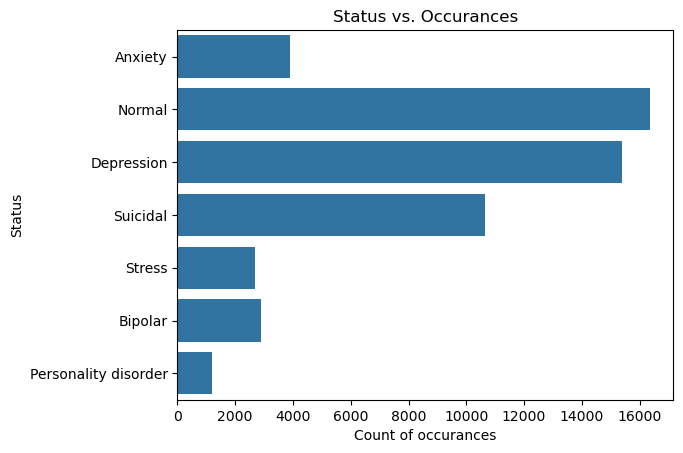

In [54]:
# visualizing status column with occurances
sns.countplot(dataset['status'])
plt.xlabel("Count of occurances")
plt.ylabel("Status")
plt.title("Status vs. Occurances")
plt.show()

### Pre-porocessing

In [55]:
# dropping "unnamed" column
columns_list = dataset.columns

dataset.drop(columns=["Unnamed: 0"], axis=1, inplace=True)

# checking the dataset after dropping column
dataset.head(5)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [56]:
# remove duplicates
print(f"shape before remove duplicates: {dataset.shape}")

dataset.drop_duplicates(inplace=True)

print(f"shape after removing duplicates: {dataset.shape}")

shape before remove duplicates: (53043, 2)
shape after removing duplicates: (51099, 2)


In [57]:
print(f"Null count of statement column {dataset['statement'].isnull().sum()}")
print(f"Null count of states column {dataset['status'].isnull().sum()}")

Null count of statement column 6
Null count of states column 0


In [58]:
# drop rows with null values (statement column)
print(f"shape before remove null rows: {dataset.shape}")

dataset.dropna(inplace=True)

print(f"shape after removing null rows: {dataset.shape}")

shape before remove null rows: (51099, 2)
shape after removing null rows: (51093, 2)


In [59]:
# removing special characters from the statements
text_1 = "Why is this cave... I'm already in a bad mood and then my heart seems to be beating really fast... I'm really nervous. Is there something wrong???"
text_2 = "Did you ever read it when you read it to RL, I mean the atmosphere, the taste. It's because I'm like this. when I read au, the topic was about mental illness ™ my days became restless....and now I'm scared."
text_3 = "I don't know if my mind breaks down, but I don't want to think about it :( , why do I feel restless?"

def format_text(content):
    text = re.sub(r"[^a-zA-Z\s']", '', content)
    return text


def remove_special_characters(content):
    cleaned_text =  re.sub('[^a-zA-Z]', ' ', content)
    return cleaned_text

dataset.head()
#cleaned_text = re.sub('[^a-zA-Z]', ' ', text_3)
#cleaned_text     

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [60]:
dataset['cleaned_text'] = dataset['statement'].apply(format_text)

In [61]:
dataset.head()

,statement,status,cleaned_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,All wrong back off dear forward doubt Stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,I've shifted my focus to something else but I'...
4,"I'm restless and restless, it's been a month n...",Anxiety,I'm restless and restless it's been a month no...


In [62]:
# expand contractions (chaing short-forms to exapdned text. Ex: I've -> I have)
text_4 = "I've been the most anxious person before I became the most sincere person, I've also been the most worried person before it all ended"
text_5 = "Sometimes it's your own thoughts that make you anxious and afraid to close your eyes until you don't sleep"
text_6 = "I've been the most anxious person before I became the most sincere person I've also been the most worried person before it all ended"

def expand_contractions(content):
    text = contractions.fix(content)
    return text

dataset['cleaned_text'] = dataset['cleaned_text'].apply(expand_contractions)

dataset.head()

,statement,status,cleaned_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,All wrong back off dear forward doubt Stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,I have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",Anxiety,I am restless and restless it is been a month ...


In [63]:
# lowercasing value
def lowercase_statement(content):
    text = content.lower()
    return text

dataset['cleaned_text'] = dataset['cleaned_text'].apply(lowercase_statement)
dataset.head()



,statement,status,cleaned_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",Anxiety,i am restless and restless it is been a month ...


In [68]:
print(f"{"-"*20} stop from here, if using BERT {"-"*20}")

#dataset['processed_text'] = dataset['cleaned_text']

# columns list
columns_list = ['statement', 'cleaned_text', 'processed_text', 'status']
columns_list

# re-index columns
#dataset = dataset.reindex(columns=columns_list)

# drop statement, cleaned_text columns
#dataset.drop(columns=[columns_list[0], columns_list[1]], axis=1, inplace=True)

# save cleaned dataset and rename as "cleaned_dataset_bert.csv"
dataset.to_csv('./dataset/cleaned_dataset_bert.csv', index=False)

dataset.head()




-------------------- stop from here, if using BERT --------------------


,processed_text,status
0,oh my gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,all wrong back off dear forward doubt stay in ...,Anxiety
3,i have shifted my focus to something else but ...,Anxiety
4,i am restless and restless it is been a month ...,Anxiety


### Tokenizing, Lemmtization, Stopwords removal


In [97]:
lemmatizer = WordNetLemmatizer()

In [ ]:
# test tokenizer
result = word_tokenize(dataset['cleaned_text'][5])
result

['every',
 'break',
 'you',
 'must',
 'be',
 'nervous',
 'like',
 'something',
 'is',
 'wrong',
 'but',
 'what',
 'the',
 'heck']

In [108]:
def preprocessing_text(content):
    processed_text = word_tokenize(content)
    processed_text = [lemmatizer.lemmatize(word) for word in processed_text if not word in stopwords.words('english')]
    processed_text = ' '.join(processed_text)

    return processed_text

In [112]:
dataset['processed_text'] = dataset['cleaned_text'].apply(preprocessing_text)

dataset.head()

,statement,status,cleaned_text,processed_text
0,oh my gosh,Anxiety,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,i have shifted my focus to something else but ...,shifted focus something else still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,i am restless and restless it is been a month ...,restless restless month boy mean


In [117]:
# re-index columns
columns_list = ['statement', 'cleaned_text', 'processed_text', 'status']

dataset = dataset.reindex(columns=columns_list)

# removing statement and cleaned_text and then save the processed data to another sheet
dataset.drop(columns=[columns_list[0], columns_list[1]], axis=1, inplace=True)

dataset.to_csv("./dataset/cleaned_dataset.csv", index=False)

In [119]:
# import cleaned dataset
cleaned_dataset = pd.read_csv('./dataset/cleaned_dataset.csv')

cleaned_dataset.head()

print(f"cleaned dataset shape : {cleaned_dataset.shape}")

cleaned dataset shape : (51093, 2)
